In [1]:
# restart kernel before reinstall updated package
%pip install --index-url https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ syng-bts==2.4

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/
Note: you may need to restart the kernel to use updated packages.


In [3]:
%load_ext autoreload
%autoreload 2

# 确保从仓库中导入，而不是从已安装的包中导入
import sys
import os

# 从当前目录向上查找包含 setup.py 的目录（即仓库根目录）
repo_root = os.path.abspath(os.getcwd())
while repo_root != os.path.dirname(repo_root):
    if os.path.exists(os.path.join(repo_root, 'setup.py')) and \
       os.path.exists(os.path.join(repo_root, 'syng_bts', 'python', 'Experiments_new.py')):
        break
    repo_root = os.path.dirname(repo_root)

# 添加仓库根目录到 sys.path 的最前面，确保优先使用本地代码
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
    print(f"使用仓库中的代码: {repo_root}")

# 现在导入，会优先使用仓库中的代码（而不是已安装的 syng-bts 包）
from syng_bts.python.Experiments_new import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#%% run pilot experiments
# This function trains VAE or CVAE, or GAN, WGAN, WGANGP, MAF, GLOW, RealNVP 
#      with several pilot size given data, model, batch_size, learning_rate, epoch, off_aug and pre_model
#      for each pilot size, there will be 5 draws, 
#      for each draw, the data is augmented to 5 times the original sample size.
# dataname :         pure data name without .csv. Eg: SKCMPositive_3
# pilot_size:        a set including potential pilot sizes
# model:             name of the model to be trained
# batch_frac:        batch fraction
# learning_rate:     learning rate 
# epoch:             choose from None (early_stop), or any interger, if choose None, early_stop_num will take effect
# early_stop_num:    if loss does not improve for early_stop_num epochs, the training will stop. Default value is 30. Only take effect when epoch == "early_stop"
# off_aug:           choose from AE_head, Gaussian_head, None. if choose AE_head, AE_head_num will take effect. If choose Gaussian_head, Gaussian_head_num will take effect. If choose None, no offline augmentation
# AE_head_num:       how many folds of AEhead augmentation needed. Default value is 2, Only take effect when off_aug == "AE_head"
# Gaussian_head_num: how many folds of Gaussianhead augmentation needed. Default value is 9, Only take effect when off_aug == "Gaussian_head"
# pre_model:         transfer learning input model. If pre_model == None, no transfer learning

PilotExperiment(dataname = "SKCMPositive_4", pilot_size = [100],
                model = "VAE1-10", batch_frac = 0.1, 
                learning_rate = 0.0005, pre_model = None,
                epoch = None,  off_aug = None, early_stop_num = 30,
                AE_head_num = 2, Gaussian_head_num = 9)

In [ ]:
#####
#####

1. Read data, path is /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/COAD_5-2_raw_batch_2_train.csv
2. Determine the model is CVAE1-100 with kl-weight = 100
3. Determine the training parameters are epoch = early_stop off_aug = No learing rate = 0.0005 batch_frac = 0.1
3. Training starts ......
Epoch: 001/10000 | Batch 0000/0010 | Loss: 42383264.0000
Epoch: 001/10000 | Batch 0001/0010 | Loss: 45066016.0000
Epoch: 001/10000 | Batch 0002/0010 | Loss: 40277576.0000
Epoch: 001/10000 | Batch 0003/0010 | Loss: 42645232.0000
Epoch: 001/10000 | Batch 0004/0010 | Loss: 42704364.0000
Epoch: 001/10000 | Batch 0005/0010 | Loss: 42864432.0000
Epoch: 001/10000 | Batch 0006/0010 | Loss: 43061896.0000
Epoch: 001/10000 | Batch 0007/0010 | Loss: 40424804.0000
Epoch: 001/10000 | Batch 0008/0010 | Loss: 40254408.0000
Epoch: 001/10000 | Batch 0009/0010 | Loss: 40951872.0000
Time elapsed: 0.00 min
Epoch: 002/10000 | Batch 0000/0010 | Loss: 39579968.0000
E

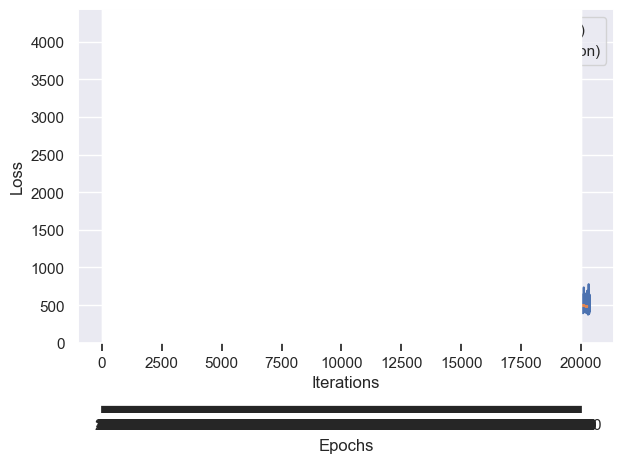

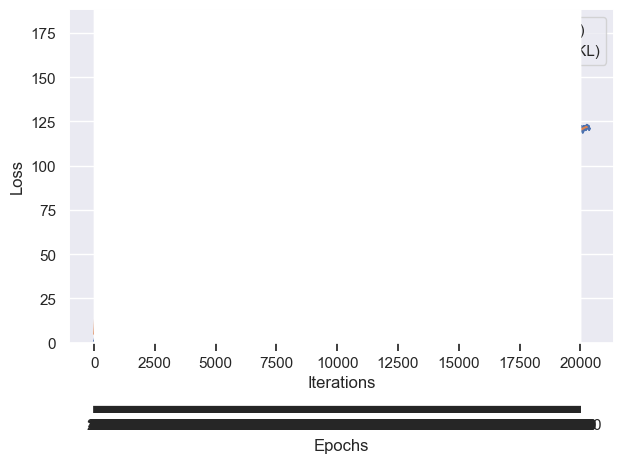

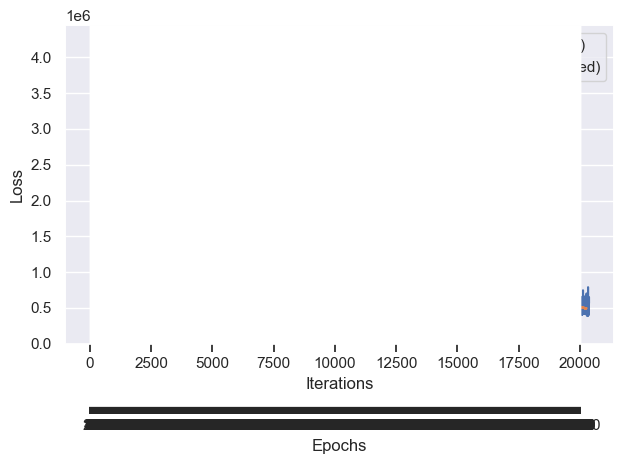

Directory created: /Users/yanjiechen
Directory created: /Users/yanjiechen/Documents
Directory created: /Users/yanjiechen/Documents/Github
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2
Directory created: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50
VAEs model training finished.
Directory created: /Users
Directory created: /Users/yanjiechen
Directory created: /Users/yanjiech

In [5]:
#%% running application on case study BRCASubtype
# This function trains VAE or CVAE, or GAN, WGAN, WGANGP, MAF, GLOW, RealNVP 
#      given data, model, batch_size, learning_rate, epoch, off_aug and pre_model
#      and generate new samples with size specified by the users.
# path:              path for reading real data and saving new data
# dataname :         pure data name without .csv. Eg: SKCMPositive_3
# apply_log:         logical whether apply log transformation before training
# model:             name of the model to be trained
# batch_frac:        batch fraction
# learning_rate:     learning rate 
# epoch:             choose from None (early_stop), or any interger, if choose None, early_stop_num will take effect
# early_stop_num:    if loss does not improve for early_stop_num epochs, the training will stop. Default value is 30. Only take effect when epoch == "early_stop"
# off_aug:           choose from AE_head, Gaussian_head, None. if choose AE_head, AE_head_num will take effect. If choose Gaussian_head, Gaussian_head_num will take effect. If choose None, no offline augmentation
# AE_head_num:       how many folds of AEhead augmentation needed. Default value is 2, Only take effect when off_aug == "AE_head"
# Gaussian_head_num: how many folds of Gaussianhead augmentation needed. Default value is 9, Only take effect when off_aug == "Gaussian_head"
# pre_model:         transfer learning input model. If pre_model == None, no transfer learning
# save_model:        if the trained model should be saved, specify the path and name of the saved model
        
ApplyExperiment(path = "/Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/",
                dataname = "COAD_5-2_raw_batch_2_train",
                apply_log = True, 
                new_size = [1000],
                model = "CVAE1-100" ,
                batch_frac = 0.1, 
                learning_rate = 0.0005,
                epoch = 10000,
                early_stop_num = 200, 
                off_aug = None,
                AE_head_num = 2,
                Gaussian_head_num = 9, 
                pre_model = None,
                save_model = None)


In [5]:
#%% Running transfer learning
# This function run transfer learning using VAE or CVAE, or GAN, WGAN, WGANGP, MAF, GLOW, RealNVP 
#      given fromdata, todata, model, batch_size, learning_rate, epoch, off_aug and pre_model
#      and generate new samples with size specified by the users.
#      The fine tuning model training can be pilot experiments or apply experiment
# Make sure data files for pre_model training and fine tuning model training are in Transfer/
# pilot_size:        if None, the fine tuning model will be apply experiment and new_size will take effect
#                    otherwise, the fine tuning model will be trained using pilot experiments
# fromname:          the dataname for pre_model training 
# toname:            the dataname for fine tuning model training
# fromsize:          the sample size of the fromdata
# new_size:          if apply experiment, this will be the sample size of generated samples
# apply_log:         logical whether apply log transformation before training
# model:             name of the model to be trained
# batch_frac:        batch fraction
# learning_rate:     learning rate 
# epoch:             choose from None (early_stop), or any interger, if choose None, early_stop_num will take effect
# off_aug:           choose from AE_head, Gaussian_head, None. if choose AE_head, AE_head_num will take effect. If choose Gaussian_head, Gaussian_head_num will take effect. If choose None, no offline augmentation
TransferExperiment(pilot_size = None, fromname = "PRAD", toname = "BRCA", fromsize = 551, 
         new_size = 500, apply_log = True, model = "maf", epoch = 10,
         batch_frac = 0.1, learning_rate = 0.0005, off_aug = None)

1. Read data, path is ../Transfer/PRAD.csv
2. Determine the model is maf with kl-weight = 1
3. Determine the training parameters are epoch = 10 off_aug = No learing rate = 0.0005 batch_frac = 0.1
3. Training starts ......

Epoch: 0


Train, Log likelihood in nats: 6631.751554: 100%|██████████| 551/551 [00:00<00:00, 1812.52it/s]


Best validation at epoch 0: Average Log Likelihood in nats: 132.3943

Epoch: 1


Train, Log likelihood in nats: 8143.614302: 100%|██████████| 551/551 [00:00<00:00, 2262.91it/s]


Best validation at epoch 1: Average Log Likelihood in nats: 162.5767

Epoch: 2


...

Best validation at epoch 7: Average Log Likelihood in nats: 43.7021

Epoch: 8


Train, Log likelihood in nats: 5403.950049: 100%|██████████| 1207/1207 [00:00<00:00, 3594.49it/s]


Best validation at epoch 8: Average Log Likelihood in nats: 44.7717

Epoch: 9


Train, Log likelihood in nats: 5529.024707: 100%|██████████| 1207/1207 [00:00<00:00, 4086.80it/s]


Best validation at epoch 9: Average Log Likelihood in nats: 45.8080
